C:\Users\umroot\anaconda3\envs\tf112\lib\site-packages\scipy\io\matlab\mio.py:208: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Loss: 0.00041834146
Loss: 0.0058641313
Loss: 0.0058641313
Loss: 0.0018376632
Loss: 0.0003780125
Loss: 0.0003655945
Loss: 0.00035641104
Loss: 0.0003316514
Loss: 0.00017219303
Loss: 0.0024437201
Loss: 0.0001634544
Loss: 0.00040582084
Loss: 0.00016175676
Loss: 0.00015897465
Loss: 0.00015877438
Loss: 0.00015843892
Loss: 0.00015737252
Loss: 0.00015541326
Loss: 0.00015042843
Loss: 0.00014025831
Loss: 0.00012767408
Loss: 0.000116043484
Loss: 0.00011238916
Loss: 0.00011283012
Loss: 0.00011173414
Loss: 0.00011154039
Loss: 0.0001110468
Loss: 0.000110810055
Loss: 0.000110721434
Loss: 0.000110666966
Loss: 0.00011043702
Loss: 0.00011001544
Loss: 0.000109113615
Loss: 0.00010721115
Loss: 0.00012426866
Loss: 0.00010531906
Loss: 0.00010910163
Loss: 0.00010430345
Loss: 0.00010229522
Loss: 0.000100931
Loss: 0.00010038175
Loss: 0.00010002172
Loss: 9.999284e-05
Loss: 9.926009e-05
Loss: 9.798053e-05
Loss: 9.657519e-05
Loss: 9.708179e-05
Loss: 9.5416624e-05
Loss: 9.4549236e-05
Loss: 9.4779236e-05
Loss: 9.418

No handles with labels found to put in legend.
C:\Users\umroot\anaconda3\envs\tf112\lib\site-packages\matplotlib\font_manager.py:1333: UserWarning: findfont: Font family ['serif'] not found. Falling back to DejaVu Sans
  (prop.get_family(), self.defaultFamily[fontext]))


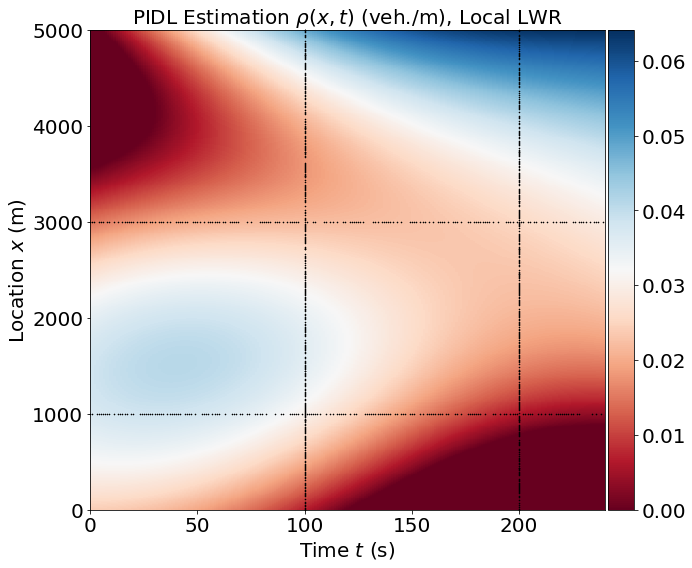

In [2]:
import sys
sys.path
sys.path.insert(0, 'PINNs-master/Utilities/')

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import griddata
from pyDOE import lhs
from plotting import newfig, savefig
from mpl_toolkits.mplot3d import Axes3D
import time
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

np.random.seed(1)
tf.set_random_seed(1)

class PhysicsInformedNN:
    def __init__(self, X_u, u, X_f, layers, lb, ub):
        
        self.lb = lb
        self.ub = ub
    
        self.x_u = X_u[:,0:1]
        self.t_u = X_u[:,1:2]
        
        self.x_f = X_f[:,0:1]
        self.t_f = X_f[:,1:2]
        
        self.u = u
        
        self.layers = layers
#         self.nu = nu
        
        # Initialize NNs
        self.weights, self.biases = self.initialize_NN(layers)
        
        # tf placeholders and graph
        self.sess = tf.Session(config=tf.ConfigProto(allow_soft_placement=True,
                                                     log_device_placement=True))
        
        self.x_u_tf = tf.placeholder(tf.float32, shape=[None, self.x_u.shape[1]])
        self.t_u_tf = tf.placeholder(tf.float32, shape=[None, self.t_u.shape[1]])        
        self.u_tf = tf.placeholder(tf.float32, shape=[None, self.u.shape[1]])
        
        self.x_f_tf = tf.placeholder(tf.float32, shape=[None, self.x_f.shape[1]])
        self.t_f_tf = tf.placeholder(tf.float32, shape=[None, self.t_f.shape[1]])        
                
        self.u_pred = self.net_u(self.x_u_tf, self.t_u_tf) 
        self.f_pred = self.net_f(self.x_f_tf, self.t_f_tf)         
        
        # integrate physics to deep learning, cost function
        self.loss = tf.reduce_mean(tf.square(self.u_tf - self.u_pred)) + tf.reduce_mean(tf.square(self.f_pred))

               
                
        self.optimizer = tf.contrib.opt.ScipyOptimizerInterface(self.loss, 
                                                                method = 'L-BFGS-B', 
                                                                options = {'maxiter': 50000,
                                                                           'maxfun': 50000,
                                                                           'maxcor': 50,
                                                                           'maxls': 50,
                                                                           'ftol' : 1.0 * np.finfo(float).eps})
        
        init = tf.global_variables_initializer()
        self.sess.run(init)
                
    def initialize_NN(self, layers):        
        weights = []
        biases = []
        num_layers = len(layers) 
        for l in range(0, num_layers-1):
            W = self.xavier_init(size=[layers[l], layers[l+1]])
            b = tf.Variable(tf.zeros([1,layers[l+1]], dtype=tf.float32), dtype=tf.float32)
            weights.append(W)
            biases.append(b)        
        return weights, biases
        
    def xavier_init(self, size):
        in_dim = size[0]
        out_dim = size[1]        
        xavier_stddev = np.sqrt(2/(in_dim + out_dim))
        return tf.Variable(tf.truncated_normal([in_dim, out_dim], stddev=xavier_stddev), dtype=tf.float32)
    
    def neural_net(self, X, weights, biases):
        num_layers = len(weights) + 1
        
        #scaling, from -1 to 1
        H = 2.0*(X - self.lb)/(self.ub - self.lb) - 1.0
        for l in range(0,num_layers-2):
            W = weights[l]
            b = biases[l]
            H = tf.tanh(tf.add(tf.matmul(H, W), b))
        W = weights[-1]
        b = biases[-1]
        Y = tf.add(tf.matmul(H, W), b)
        return Y
            
    def net_u(self, x, t):
        u = self.neural_net(tf.concat([x,t],1), self.weights, self.biases)
        u = tf.clip_by_value(u, clip_value_min=0, clip_value_max=0.1)
        return u
    
    def net_f(self, x,t):
        u = self.net_u(x,t)
        u_t = tf.gradients(u, t)[0]
        u_x = tf.gradients(u, x)[0]
        f = u_t + 25 * u_x - (2 * 25 / 0.05) * u * u_x
        return f

    
    def callback(self, loss):
        print('Loss:', loss)
        
    def train(self):     
        tf_dict = {self.x_u_tf: self.x_u, self.t_u_tf: self.t_u, self.u_tf: self.u,
                   self.x_f_tf: self.x_f, self.t_f_tf: self.t_f}                                                                                                                       
        self.optimizer.minimize(self.sess, 
                                feed_dict = tf_dict,         
                                fetches = [self.loss], 
                                loss_callback = self.callback)        
                                    
    def predict(self, X_star):       
        u_star = self.sess.run(self.u_pred, {self.x_u_tf: X_star[:,0:1], self.t_u_tf: X_star[:,1:2]})  
        f_star = self.sess.run(self.f_pred, {self.x_f_tf: X_star[:,0:1], self.t_f_tf: X_star[:,1:2]})   
        return u_star, f_star

np.random.seed(1)
tf.set_random_seed(1)

N_u = 1000
N_f = 20000
# layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]
layers = [2, 50, 50, 50, 50, 50, 50, 50, 50, 50, 1]

data = scipy.io.loadmat('data-synthetic.mat')


t = data['tScale'].T.flatten()[:,None]
x = data['xScale'].T.flatten()[:,None]
Exact = np.real(data['k'])
X, T = np.meshgrid(x,t)

X_star = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))
u_star = Exact.flatten()[:,None]              
lb = X_star.min(0)
ub = X_star.max(0)     


############################### Training Data #################################
# ############################### Training Data #################################
# Eulerian samples: only sample data on four designated lines (x=1000, x=3000, t=100, t=200)
x_lines = [1000.0, 3000.0]
t_lines = [100.0, 200.0]
tol = 1e-6  # tolerance for floating comparisons; increase (e.g., 1e-3) if no points match

x_all = X_star[:, 0]
t_all = X_star[:, 1]

mask_x = np.zeros_like(x_all, dtype=bool)
for xv in x_lines:
    mask_x |= np.abs(x_all - xv) < tol

mask_t = np.zeros_like(t_all, dtype=bool)
for tv in t_lines:
    mask_t |= np.abs(t_all - tv) < tol

mask = mask_x | mask_t

candidate_idx = np.where(mask)[0]
if candidate_idx.size == 0:
    raise ValueError("No points matched the requested Eulerian lines. Increase tol or choose line values on the grid.")

if candidate_idx.size >= N_u:
    idx = np.random.choice(candidate_idx, N_u, replace=False)
else:
    idx = candidate_idx  

X_u_train = X_star[idx, :]
u_train = u_star[idx, :]
# ######################### Collocation Points #################################
X_f_train = lb + (ub - lb) * lhs(2, N_f)
X_f_train = np.vstack((X_f_train, X_u_train))

model = PhysicsInformedNN(X_u_train, u_train, X_f_train, layers, lb, ub)

start_time = time.time()                
model.train()
elapsed = time.time() - start_time                
print('Training time: %.4f' % (elapsed))
u_pred, f_pred = model.predict(X_star)
error_u = np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2)
print('Error u: %e' % (error_u))                     
U_pred = griddata(X_star, u_pred.flatten(), (X, T), method='cubic')
Error = np.abs(Exact - U_pred)

fig, ax = newfig(2, 1)
ax.axis('off')

####### Row 0: PIDL: u(t,x) ##################    
gs0 = gridspec.GridSpec(1, 2)
gs0.update(top=1, bottom=0, left=0.15, right=0.85, wspace=0)
ax = plt.subplot(gs0[:, :])
ax.tick_params(axis='both', which='major', labelsize=20)

h = ax.imshow(U_pred.T, interpolation='nearest', cmap='RdBu', 
              extent=[t.min(), t.max(), x.min(), x.max()], 
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cax.tick_params(labelsize=20)
fig.colorbar(h, cax=cax)

ax.plot(X_u_train[:,1], X_u_train[:,0], 'kx', markersize = 1, clip_on = False)

ax.set_xlabel('Time $t$ (s)', fontsize = 20)
ax.set_ylabel('Location $x$ (m)', fontsize = 20)
ax.legend(frameon=False, loc = 'best', fontsize = 20)
ax.set_title('PIDL Estimation $\\rho (x,t)$ (veh./m), Local LWR', fontsize = 20)

savefig('figures/pidl_1k_20k')